In [1]:
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
from shapely import wkt
import numpy as np
import re
import folium
import ast
import branca
from shapely import LineString, MultiLineString
from pathlib import Path
import math
from branca.element import Template, MacroElement
from scipy import stats
from matplotlib.offsetbox import AnchoredText


In [2]:
comparison_df = pd.read_csv('../routing/all_scored_edges_filtered_with_ai.csv')
buffer = pd.read_csv("../crime/data/scores/edges_with_safety_score_point_buffer_25m.csv")
density = pd.read_csv("../crime_density/density_scores/cds_67.csv")
light_df = pd.read_csv('newlightpoles.csv')

light_df_filtered = light_df[light_df["highway"] == "footway"].copy()
comparison_df['ldensity'] = light_df_filtered['ldensity'].to_numpy()* 0.9 + 0.1

/var/folders/92/3gykpnwj75zc04j2_wnxhtcw0000gn/T/ipykernel_5196/1172584759.py:1: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  comparison_df = pd.read_csv('../routing/all_scored_edges_filtered_with_ai.csv')
/var/folders/92/3gykpnwj75zc04j2_wnxhtcw0000gn/T/ipykernel_5196/1172584759.py:3: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  density = pd.read_csv("../crime_density/density_scores/cds_67.csv")
/var/folders/92/3gykpnwj75zc04j2_wnxhtcw0000gn/T/ipykernel_5196/1172584759.py:4: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  light_df = pd.read_csv('newlightpoles.csv')


In [28]:
print(comparison_df["safety_score_night_density"].describe(), comparison_df.columns)

count    18972.000000
mean         0.885175
std          0.071993
min          0.271000
25%          0.855038
50%          0.901097
75%          0.933309
max          0.997286
Name: safety_score_night_density, dtype: float64 Index(['Unnamed: 0.3', 'Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', 'u', 'v',
       'key', 'osm_id', 'highway', 'oneway', 'reversed', 'length', 'lanes',
       'maxspeed', 'name', 'access', 'service', 'geometry', 'bridge', 'tunnel',
       'ref', 'sidewalk_notes', 'access_score', 'slope_notes',
       'safety_score_day_buffer', 'safety_score_night_buffer',
       'safety_score_day_density', 'safety_score_night_density', 'travel_time',
       'AI_avg_appeal_score', 'AI_avg_safety_score',
       'AI_avg_accessibility_score', 'AI_avg_total_score', 'point_count',
       'ai_buffer_day_average', 'ai_density_day_average',
       'ai_buffer_night_average', 'ai_density_night_average',
       'ai_access_average', 'slope_score_u_v', 'slope_score_v_u', 'elevations',
       

In [5]:
light_df['ldensity'].describe()
comparison_df["ldensity"].describe()

count    18972.000000
mean         0.196117
std          0.171233
min          0.100000
25%          0.100000
50%          0.140329
75%          0.194781
max          1.000000
Name: ldensity, dtype: float64

In [6]:
print(comparison_df[["u","v"]].head(), comparison_df.shape[0])
print(light_df_filtered[["u","v"]].head(), light_df_filtered.shape[0])
print(buffer[["u","v"]].head(), buffer.shape[0])
print(density[["u","v"]].head(), density.shape[0])


          u            v
0  29938143    321336630
1  53018668   5321393680
2  53018668   3916774511
3  53018668  10743226133
4  53025077   8362857777 18972
           u            v
0   29938143    321336630
8   53018668   5321393680
9   53018668   3916774511
10  53018668  10743226133
16  53025077   8362857777 18972
          u            v
0  29938143    321336630
1  53018668   5321393680
2  53018668   3916774511
3  53018668  10743226133
4  53025077   8362857777 18972
          u            v
0  29938143    321336630
1  53018668   5321393680
2  53018668   3916774511
3  53018668  10743226133
4  53025077   8362857777 18972


In [3]:
# night score ONLY (no day, no light)
comparison_df["density_night_only"] = density["safety_score_night_density"]
comparison_df["buffer_night_only"] = buffer["buffer_night"]

# make new df
scores = comparison_df[["u", "v", "key", "osm_id", "geometry", "safety_score_night_density", "safety_score_night_buffer", "density_night_only", "buffer_night_only", "ldensity"]].copy()

# night score with LIGHT ONLY, no day
scores["buffer_with_light"] = (scores["buffer_night_only"] * (1+0.2 *(scores['ldensity']))).clip(0, 1)
scores["density_with_light"] = (scores["density_night_only"] * (1+0.2 *(scores['ldensity']))).clip(0, 1)

# night score with DAY AND LIGHT
scores["safety_score_night_density"] = comparison_df["safety_score_night_density"]
scores["safety_score_night_buffer"] = comparison_df["safety_score_night_buffer"]



In [4]:
# calculate differences
scores['buffer_diff'] = scores['buffer_night_only'] - scores['safety_score_night_buffer']
scores['density_diff'] = scores['density_night_only'] - scores['safety_score_night_density']
scores['night_diff'] = scores['buffer_night_only'] - scores['density_night_only']
scores['final_diff'] = scores['safety_score_night_buffer'] - scores['safety_score_night_density']

scores["buffer_light_diff"] = scores['buffer_night_only'] - scores['buffer_with_light']
scores["density_light_diff"] = scores['density_night_only'] - scores['density_with_light']

# prepare gdf
scores["geometry"] = scores["geometry"].apply(wkt.loads)
gdf = gpd.GeoDataFrame(scores, geometry='geometry', crs='EPSG:3857')

<div style="
    text-align: center;
    max-width: 600px;
    margin: 0 auto;
    background:
    rgba(62, 128, 234, 1);
    color: white;
    padding: 12px;
    border-radius: 4px;
">
  <h3> ★ do not modify functions ★ </h3>
  <p> The cells below plot a folium map of the differences between two values.</p>
  <p> The cell directly below can be modified to compute the difference columns.</p>
  <p> For a difference of a - b, blue indicates that a is lower, whereas red indicates that a is higher.</p>
  <p> The map can be saved and displayed in multiple ways.</p>
</div>

In [ ]:
def screenshot_folium_html(
    html_path: str,
    png_path: str,
    *,
    wait_timeout: int = 25,
    extra_delay: float = 0.9,
    window_size: tuple = (1600, 1200),
    element_only: bool = True,
    zoom_in_steps: int = 0
):
    """
    Open a local Folium HTML in headless Chromium, optionally zoom in/out,
    then save a PNG. Robustly locates the Folium 'map_<hash>' object.
    """
    import os, time
    from selenium import webdriver
    from selenium.webdriver.chrome.options import Options
    from selenium.webdriver.chrome.service import Service
    from selenium.webdriver.common.by import By
    from selenium.webdriver.support.ui import WebDriverWait
    from selenium.webdriver.support import expected_conditions as EC
    from webdriver_manager.chrome import ChromeDriverManager

    file_url = "file://" + os.path.abspath(html_path)

    opts = Options()
    opts.add_argument("--headless=new")
    opts.add_argument("--no-sandbox")
    opts.add_argument("--disable-dev-shm-usage")
    opts.add_argument(f"--window-size={window_size[0]},{window_size[1]}")

    driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=opts)
    try:
        driver.get(file_url)

        wait = WebDriverWait(driver, wait_timeout)
        # wait for the Folium container to exist
        folium_el = wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, ".folium-map")))

        # wait until at least one Leaflet map object (map_<hash>) is available
        map_var = wait.until(lambda d: d.execute_script("""
            // Find a window variable named 'map_<hash>' that looks like a Leaflet map
            for (const k of Object.keys(window)) {
                if (k.startsWith('map_')) {
                    const m = window[k];
                    if (m && typeof m.setZoom === 'function' && typeof m.invalidateSize === 'function') {
                        return k;
                    }
                }
            }
            return null;
        """))

        # check if initial tiles have loaded
        wait.until(lambda d: d.execute_script(
            "return document.querySelectorAll('.leaflet-tile-loading').length === 0"
        ))

        # apply relative zoom
        if zoom_in_steps != 0:
            driver.execute_script(f"""
                var m = window['{map_var}'];
                try {{ m.invalidateSize(true); }} catch(e) {{}}
                // zoomIn accepts a positive integer; for negative we use zoomOut
                var steps = {int(zoom_in_steps)};
                if (steps > 0) {{
                    m.zoomIn(steps);
                }} else if (steps < 0) {{
                    m.zoomOut(-steps);
                }}
            """)
            # wait for any new tiles to load after zoom change
            wait.until(lambda d: d.execute_script(
                "return document.querySelectorAll('.leaflet-tile-loading').length === 0"
            ))

        time.sleep(extra_delay)

        # screenshot and save
        if element_only:
            folium_el.screenshot(png_path)
        else:
            driver.save_screenshot(png_path)

        print(f"[saved] {png_path}")
    finally:
        driver.quit()



In [34]:
def plot_diff(KEYWORD, PATH_TO_SAVE, CAPTION, NOTE_BODY):
    """
        Creates a Folium map of a computed difference column. Automatically saved as both a .html file and a png.
    """

    bounds = gdf.total_bounds
    center_lat = (bounds[1] + bounds[3]) / 2
    center_lon = (bounds[0] + bounds[2]) / 2

    s = pd.to_numeric(gdf[KEYWORD], errors="coerce")
    rng = max(abs(s.min(skipna=True)), abs(s.max(skipna=True)))
    if pd.isna(rng) or rng == 0:
        rng = 1e-9

    vmin, vmax = -rng, rng

    m = folium.Map(location=[center_lat, center_lon], zoom_start=14, tiles="cartodbpositron")


    # for note/description
    template = """
    {{% macro html(this, args) %}}
    <div style="
        position: fixed;
        bottom: 10px;
        left: 10px;
        width: 250px;
        background-color: white;
        border: 1px solid #ccc;
        padding: 8px;
        font-size: 12px;
        line-height: 1.3;
        box-shadow: 2px 2px 6px rgba(0,0,0,0.3);
        z-index:9999;
    ">
        <strong>Note:</strong><br>
        {NOTE_BODY}<br>
    </div>
    {{% endmacro %}}
    """
    template = template.format(NOTE_BODY=NOTE_BODY)

    # turn to macroelement, add to plot
    footnote = MacroElement()
    footnote._template = Template(template)
    m.get_root().add_child(footnote)

    colormap = branca.colormap.LinearColormap(
        colors=["blue", "white", "red"],
        vmin=vmin,
        vmax=vmax,
        caption=CAPTION
    )
    colormap.add_to(m)

    # loop through each road segment
    for _, row in gdf.iterrows():
        geom = row.geometry

        # extract linestrings
        if isinstance(geom, LineString):
            lines = [geom]
        elif isinstance(geom, MultiLineString):
            lines = list(geom.geoms)
        else:
            continue

        # tooltip changed for crime
        # get the length
        length_val = row.get("length", None)
        if length_val is not None and not pd.isna(length_val):
            length_text = f"{length_val:.1f}"
        else:
            length_text = "N/A"

        tooltip_html = f"""
        <b>OSM ID:</b> {row.osm_id}<br>
        <b>{CAPTION}:</b> {row[KEYWORD]:.3f}<br>
        <b>Length (m):</b> {length_text}<br>
        """
        # draw each linestring
        for line in lines:
            coords = [(pt[1], pt[0]) for pt in line.coords]  # folium needs (lat, lon), so flip them
            folium.PolyLine(
                locations=coords,
                color=colormap(row[KEYWORD]),
                weight=4,
                opacity=0.8,
                tooltip=folium.Tooltip(tooltip_html, sticky=True)
            ).add_to(m)

    colormap.add_to(m)

    # save map first
    m.save(PATH_TO_SAVE)

    # get map and screenshot to save as img
    screenshot_folium_html(f"{PATH_TO_SAVE}", f"data/images_plots/{KEYWORD}.png", zoom_in_steps=1, window_size=(1600, 1200), element_only=True)

In [ ]:
KEYWORD = 'buffer_diff'
PATH_TO_SAVE = f'diff_maps/data/{KEYWORD}.html'
CAPTION = "Buffer Night Only Score vs. Buffer Final Score"
NOTE_BODY = """
    If the color at a location is blue, the night score is greater than the final score. If the
    color at a location is red, the final score is greater than the night score. A more saturated
    blue/red color signifies a higher difference between the two scores. White indicates there is little to no difference.
"""
plot_diff(KEYWORD, PATH_TO_SAVE, CAPTION, NOTE_BODY)


KEYWORD = 'density_diff'
PATH_TO_SAVE = f'diff_maps/data/{KEYWORD}.html'
CAPTION = "Density Night Only Score vs. Density Final Score"
NOTE_BODY = """
    If the color at a location is blue, the night score is greater than the final score. If the
    color at a location is red, the final score is greater than the night score. A more saturated
    blue/red color signifies a higher difference between the two scores. White indicates there is little to no difference.
"""
plot_diff(KEYWORD, PATH_TO_SAVE, CAPTION, NOTE_BODY)


KEYWORD = 'night_diff'
PATH_TO_SAVE = f'diff_maps/data/{KEYWORD}.html'
CAPTION = "Buffer Night Only Score vs. Density Night Only Score"
NOTE_BODY = """
    If the color at a location is blue, the buffer score is greater than the density score. If the
    color at a location is red, the density score is greater than the buffer score. A more saturated
    blue/red color signifies a higher difference between the two scores. White indicates there is little to no difference.
"""
plot_diff(KEYWORD, PATH_TO_SAVE, CAPTION, NOTE_BODY)


KEYWORD = 'final_diff'
PATH_TO_SAVE = f'diff_maps/data/{KEYWORD}.html'
CAPTION = "Buffer Final Score vs. Density Final Score"
NOTE_BODY = """
    If the color at a location is blue, the buffer score is greater than the density score. If the
    color at a location is red, the density score is greater than the buffer score. A more saturated
    blue/red color signifies a higher difference between the two scores. White indicates there is little to no difference.
"""
plot_diff(KEYWORD, PATH_TO_SAVE, CAPTION, NOTE_BODY)

[saved] data/images_plots/buffer_diff.png
[saved] data/images_plots/density_diff.png
[saved] data/images_plots/night_diff.png
[saved] data/images_plots/final_diff.png


In [ ]:
KEYWORD = 'buffer_light_diff'
PATH_TO_SAVE = f'diff_maps/data/{KEYWORD}.html'
CAPTION = "Buffer Night Only Score vs. Buffer with Light Score"
NOTE_BODY = """
    If the color at a location is blue, the buffer night only score is greater than the buffer with light score. If the
    color at a location is red, the density score is greater than the buffer score. A more saturated
    blue/red color signifies a higher difference between the two scores. White indicates there is little to no difference.
"""
plot_diff(KEYWORD, PATH_TO_SAVE, CAPTION, NOTE_BODY)


KEYWORD = 'density_light_diff'
PATH_TO_SAVE = f'diff_maps/data/{KEYWORD}.html'
CAPTION = "Density Night Only Score vs. Density with Light Score"
NOTE_BODY = """
    If the color at a location is blue, the density night only score is greater than the density with light score. If the
    color at a location is red, the density score is greater than the buffer score. A more saturated
    blue/red color signifies a higher difference between the two scores. White indicates there is little to no difference.
"""
plot_diff(KEYWORD, PATH_TO_SAVE, CAPTION, NOTE_BODY)

[saved] data/images_plots/buffer_light_diff.png
[saved] data/images_plots/density_light_diff.png


<div style="
    text-align: center;
    max-width: 600px;
    margin: 0 auto;
    background:
    rgba(62, 128, 234, 1);
    color: white;
    padding: 12px;
    border-radius: 4px;
">
  <h3> ★ live server ★ </h3>
  <p> The cell below opens a live server and dynamically displays the html difference folium maps.</p>
  <p> Run the next cell to close the server when you are done. Closing the server will not close the html maps.</p>
  <p> If it says a port is being used even after closing, you can just switch between two ports and it should work fine.</p>
  <p> Try not to use too much, large load.</p>
</div>

In [ ]:
# import threading
# import http.server
# import socketserver
# from IPython.display import HTML
# import os

# # 1. set your directory and file list
# map_dir = "."
# num = 4
# paths = [
#     "data/buffer_diff.html",
#     "data/density_diff.html",
#     "data/night_diff.html",
#     "data/final_diff.html",
# ]

# # 2. start simple HTTP server on localhost:8000
# PORT = 8000
# os.chdir(map_dir)  # serve files from map_dir
# Handler = http.server.SimpleHTTPRequestHandler
# httpd = socketserver.TCPServer(("", PORT), Handler)

# # run it in a thread so it doesn't block your notebook
# thread = threading.Thread(target=httpd.serve_forever, daemon=True)
# thread.start()

# # 3. build an HTML flexbox of labelled iframes
# html = "<div style='display:flex; flex-direction:column; gap:16px; align-items:flex-start; width:100%;'>"
# for fn in paths:
#     url = f"http://localhost:{PORT}/{fn}"
#     label = fn.replace(".html","").replace("_"," ").title()
#     html += (
#         "<div style='text-align:left; font-family:Arial, sans-serif;'>"
#         f"<div style='font-size:14px; font-weight:600; margin-bottom:6px;'>{label}</div>"
#         f"<iframe src='{url}' width=800' height='700' style='border:1px solid #ccc; overflow:visible'></iframe>"
#         "</div>"
#     )
# html += "</div>"

# HTML(html)


<div style="
    text-align: center;
    max-width: 600px;
    margin: 0 auto;
    background:
    rgba(62, 128, 234, 1);
    color: white;
    padding: 12px;
    border-radius: 4px;
">
  <h3> ★ please close server when done ★ </h3>
</div>

In [5]:
# httpd.shutdown()
# httpd.server_close()
# thread.join()  

<div style="
    text-align: center;
    max-width: 600px;
    margin: 0 auto;
    background:
    rgba(62, 128, 234, 1);
    color: white;
    padding: 12px;
    border-radius: 4px;
">
  <h3> ★ correlation analysis ★ </h3>
  <p> Correlation plots between Light, Buffer, and Density scores. </p>
</div>

In [5]:
def plot_correlation(col1, col2):
    x = scores[col1]
    y = scores[col2]
    mask = pd.notna(x) & pd.notna(y)
    x = x[mask]; y = y[mask]

    # get stats
    r, p = stats.pearsonr(x, y)
    slope, intercept, r_val, p_val, std_err = stats.linregress(x, y)
    print(f"Pearson r = {r:.3f}, p‑value = {p:.3e}, slope={slope:.3f}, intercept={intercept:.3f}, R²={r_val**2:.3f}")

    stats_txt = (
        f"Pearson r = {r:.3f},"
        f"p-value = {p:.2e}\n"
        f"slope = {slope:.3f}, "
        f"intercept = {intercept:.3f}, "
        f"R² = {r_val:.3f}"
    )

    # plot points
    plt.figure(figsize=(6,5))
    plt.scatter(x, y,
                color='orange',
                marker='o',
                alpha=0.7,
                label='data points')

    # plot best fit
    xx = np.linspace(x.min(), x.max(), 100)
    plt.plot(xx,
            intercept + slope*xx,
            color='red',
            linewidth=2,
            label='best‑fit line')

    # add space for text labels
    ax = plt.gca()
    fig = plt.gcf()
    fig.subplots_adjust(bottom=0.28)
    ax.text(
        0.02, -0.18, stats_txt,
        transform=ax.transAxes,
        ha="left", va="top",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.5", alpha=0.9),
    )

    plt.xlabel(col1)
    plt.ylabel(col2)
    plt.title(f"{col1} vs. {col2}")
    plt.legend()
    plt.tight_layout()
    plt.show()


Pearson r = -0.216, p‑value = 2.349e-199, slope=-0.147, intercept=0.323, R²=0.047


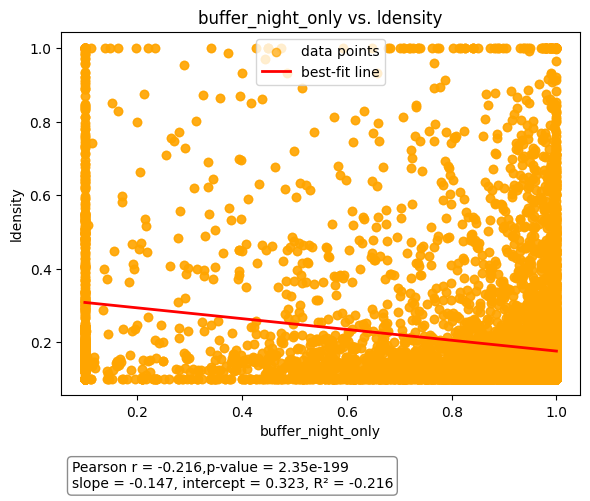

Pearson r = -0.103, p‑value = 3.689e-46, slope=-0.205, intercept=0.379, R²=0.011


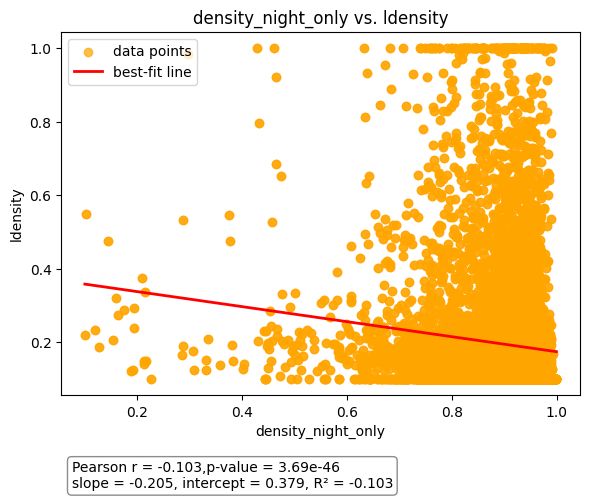

Pearson r = -0.182, p‑value = 1.717e-141, slope=-0.125, intercept=0.305, R²=0.033


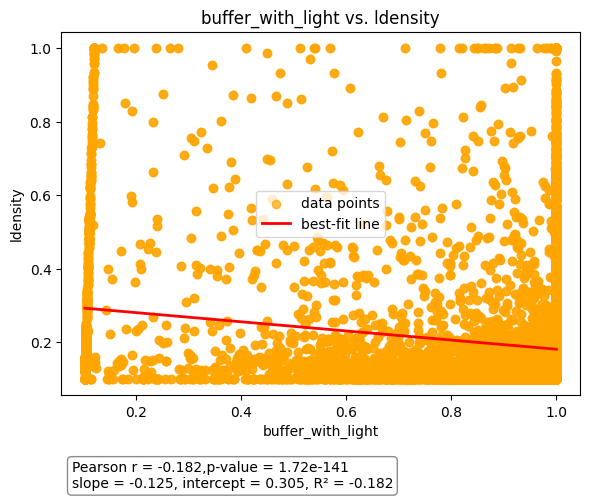

Pearson r = 0.108, p‑value = 2.361e-50, slope=0.212, intercept=0.001, R²=0.012


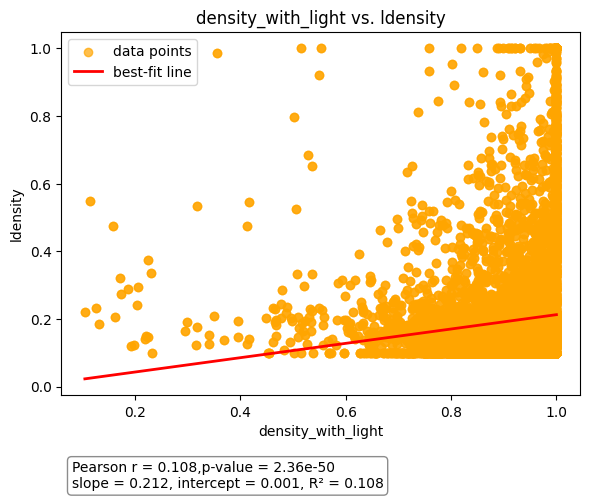

Pearson r = -0.222, p‑value = 1.609e-210, slope=-0.142, intercept=0.314, R²=0.049


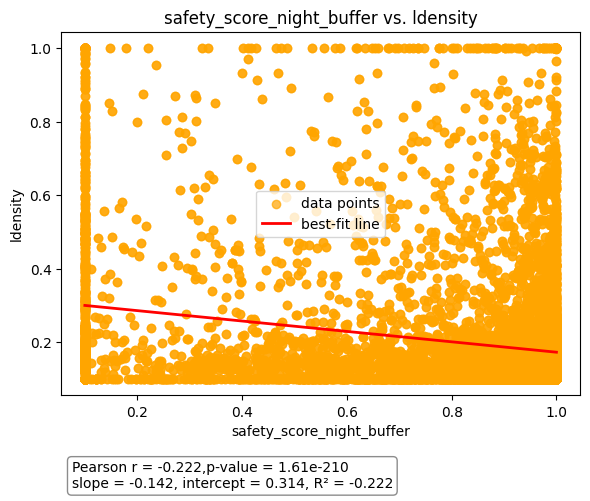

Pearson r = -0.056, p‑value = 1.434e-14, slope=-0.133, intercept=0.314, R²=0.003


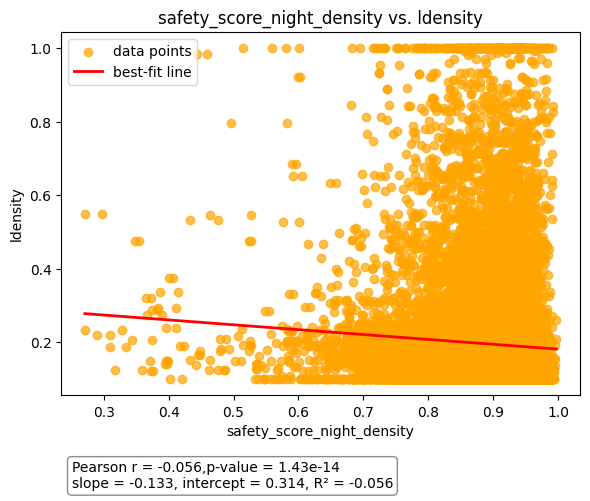

In [9]:
plot_correlation("buffer_night_only", "ldensity")
plot_correlation("density_night_only", "ldensity")
plot_correlation("buffer_with_light", "ldensity")
plot_correlation("density_with_light", "ldensity")
plot_correlation("safety_score_night_buffer", "ldensity")
plot_correlation("safety_score_night_density", "ldensity")

Pearson r = 0.970, p‑value = 0.000e+00, slope=1.036, intercept=-0.058, R²=0.940


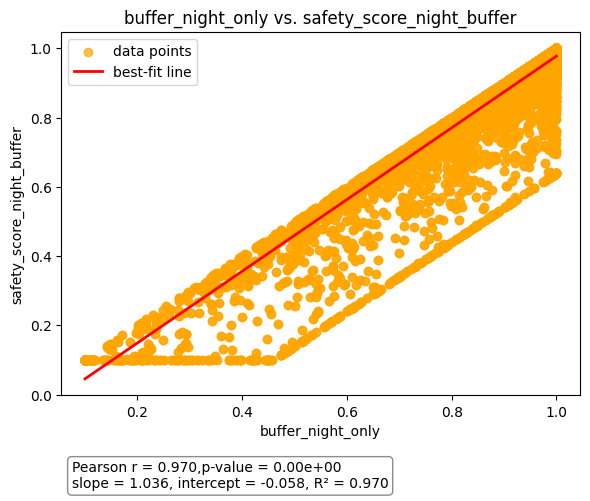

Pearson r = 0.856, p‑value = 0.000e+00, slope=0.713, intercept=0.249, R²=0.733


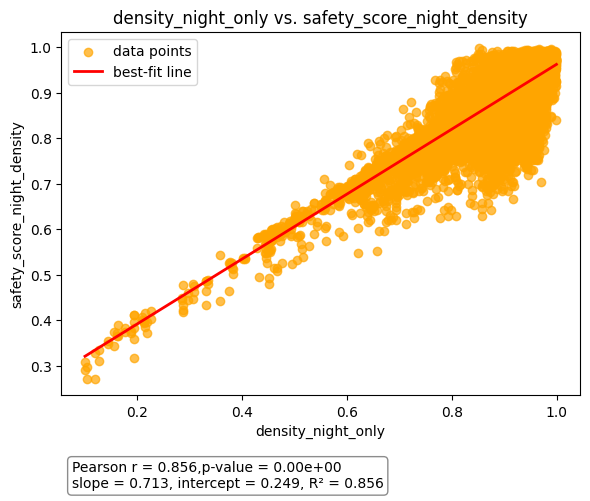

In [10]:
plot_correlation("buffer_night_only", "safety_score_night_buffer")
plot_correlation("density_night_only", "safety_score_night_density")


Pearson r = 0.997, p‑value = 0.000e+00, slope=0.994, intercept=0.020, R²=0.995


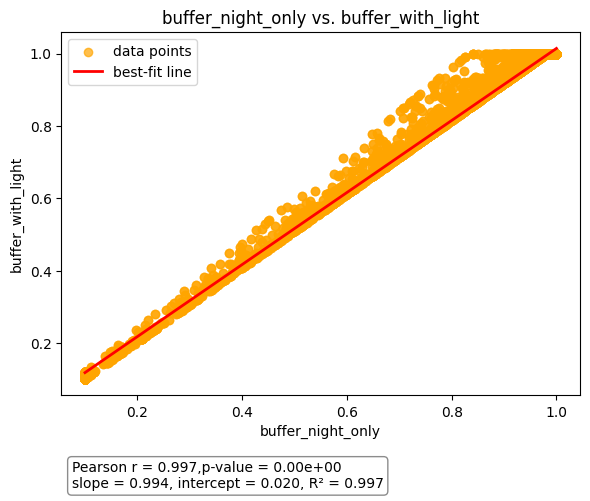

Pearson r = 0.970, p‑value = 0.000e+00, slope=0.979, intercept=0.049, R²=0.941


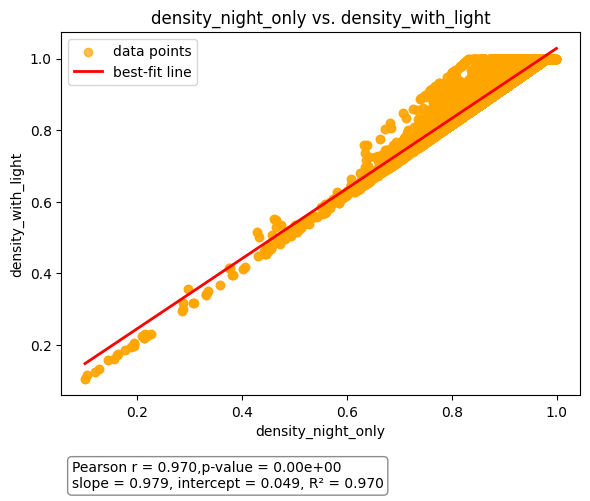

Pearson r = 0.561, p‑value = 0.000e+00, slope=0.193, intercept=0.726, R²=0.314


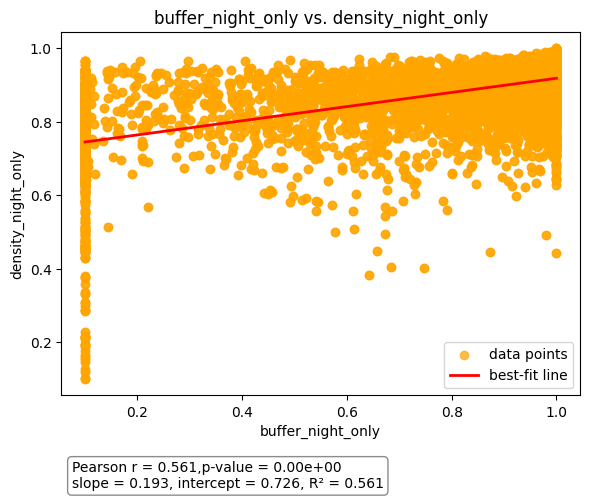

Pearson r = 0.507, p‑value = 0.000e+00, slope=0.177, intercept=0.768, R²=0.257


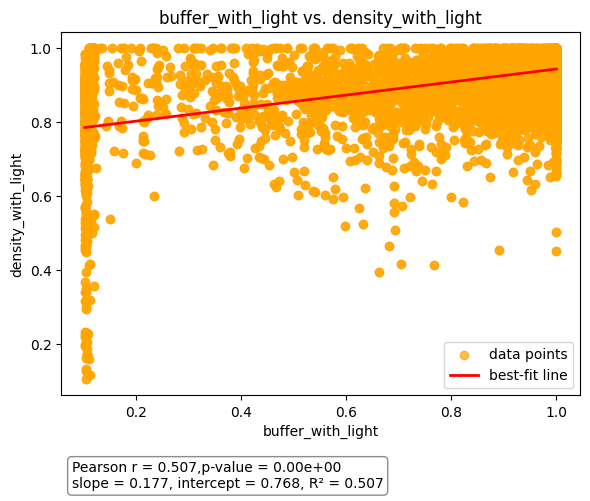

Pearson r = 0.460, p‑value = 0.000e+00, slope=0.123, intercept=0.782, R²=0.211


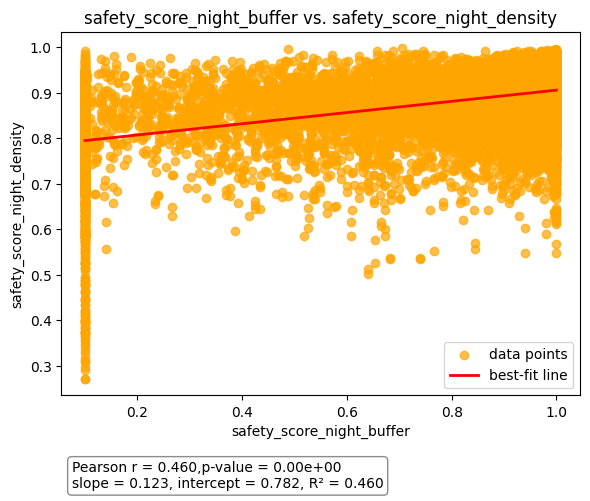

In [ ]:
# plot different columns against each other
plot_correlation("buffer_night_only", "buffer_with_light")
plot_correlation("density_night_only", "density_with_light")
plot_correlation("buffer_night_only", "density_night_only")
plot_correlation("buffer_with_light", "density_with_light")
plot_correlation("safety_score_night_buffer", "safety_score_night_density")


<div style="
    text-align: center;
    max-width: 600px;
    margin: 0 auto;
    background:
    rgba(62, 128, 234, 1);
    color: white;
    padding: 12px;
    border-radius: 4px;
">
  <h3> ★ statistical analysis ★ </h3>
  <p> Stat table of scores between Light, Buffer, and Density scores. </p>
</div>

In [ ]:
# columns to be in the table
score_cols = [
    "buffer_night_only",
    "buffer_with_light",
    "safety_score_night_buffer",
    "density_night_only",
    "density_with_light", 
    "safety_score_night_density" 
]

In [ ]:
# change display options
pd.set_option("display.width", 0)
pd.set_option("display.expand_frame_repr", False)

# get summary stats for each column
summary = scores[score_cols].describe().T
summary = summary.transpose()

# save table as image
def table_format_save(table: pd.DataFrame, name: str, out_dir: Path) -> None:
    from html2image import Html2Image

    table_html = table.to_html(index=True, border=0, classes="zebra")
    title_html = f"<h2 class='title'>{name.capitalize()} Summary</h2>"

    # zebra rows, sticky header, subtle borders, readable font
    full_html = f"""
    <html>
    <head>
      <meta charset="utf-8" />
      <style>
        :root {{
          --bg-even: #edf8ff;
          --bg-odd:  #ffffff;
          --border:  #d1d5db;
          --header-bg: #c7e8ff;
          --header-fg: #000000;
          --text: #000000;
        }}
        * {{
          box-sizing: border-box;
        }}
        body {{
          background: white;
          margin: 0;
          padding: 12px;
          font-family: system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial, "Apple Color Emoji", "Segoe UI Emoji";
          color: var(--text);
        }}
        .title {{
          font-size: 20px;
          font-weight: bold;
          margin-bottom: 12px;
          text-align: center;
        }}
        table {{
          border-collapse: separate;
          border-spacing: 0;
          width: 100%;
          overflow: hidden;
          border: 1px solid var(--border);
          border-radius: 12px;
        }}
        thead th {{
          position: sticky;
          top: 0;
          background: var(--header-bg);
          color: var(--header-fg);
          text-align: right;
          padding: 10px 12px;
          font-weight: 600;
          border-bottom: 1px solid var(--border);
          white-space: nowrap;
        }}
        tbody td {{
          padding: 8px 12px;
          border-bottom: 1px solid var(--border);
          text-align: right;
          white-space: nowrap;
        }}
        tbody tr:nth-child(odd)  {{ background: var(--bg-odd);  }}
        tbody tr:nth-child(even) {{ background: var(--bg-even); }}

        /* Rounded corners */
        thead th:first-child {{ text-align: left; border-top-left-radius: 12px; }}
        thead th:last-child  {{ border-top-right-radius: 12px; }}
        tbody tr:last-child td:first-child {{ border-bottom-left-radius: 12px; }}
        tbody tr:last-child td:last-child  {{ border-bottom-right-radius: 12px; }}

        /* Left-align the first column (dataset names) for readability */
        thead th:first-child, tbody td:first-child {{ text-align: left; }}
      </style>
    </head>
    <body>
      {title_html}
      {table_html}
    </body>
    </html>
    """

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    # save screenshot, adjust size if needed
    hti = Html2Image(output_path=str(out_dir))
    hti.screenshot(
        html_str=full_html,
        save_as=f"{name}_summary_table.png",
        size=(1300, 500)
    )

table_format_save(summary, "buffer_density_comparison", "data/tables")


64190 bytes written to file /Users/alice/Documents/GitHub/STARSWalkability/safety/data/tables/buffer_density_comparison_summary_table.png
